# **Face and Eye Detection with Haar Cascade Classifiers**

## **In this lesson we'll learn:**
1. To use a Haarcascade Classifer to detect faces
2. To use a Haarcascade Classifer to detect eyes
3. To use a Haarcascade Classifer to detect faces and eyes from your webcam in Colab


> **Assets note.** The original asset pack for this course was never committed to this repo (no `images/`, `videos/`, or `haarcascades/`, in any past commit). This fork ships a real, working replacement set — sourced from OpenCV's own official sample data where a good match existed, generated procedurally where it didn't (see `scripts/generate_assets.py`) — under `assets/images/`, `assets/videos/`, and `assets/haarcascades/`, plus small, called-out fixes wherever a swap needed one. Nothing else was removed. See the README for the full source list. No download step needed — just run the cells top to bottom.

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function 
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **Simple Face Detection using Haarcascade Classifiers**

This is a simple face detection program that uses the OpenCV library to detect faces in an image or video stream. The code consists of two main functions


**Object Detection** is the ability to detect and classify individual objects in an image and draw a bounding box over the object's area. 

**HAAR Casccade Classifiers** An object detection method that uses a series of classifiers (cascade) to identify objects in an image. They are trained to identify one type of object, however, we can use several of them in parallel e.g. detecting eyes and faces together. HAAR Classifiers are trained using lots of positive images (i.e. images with the object present) and negative images (i.e. images without the object present).


### What a Haar-like feature actually measures

A Haar feature is almost embarrassingly simple: lay a small rectangle over the image, split it into light/dark sub-regions (say, top half vs. bottom half), and compute *(sum of pixels under the white part) − (sum under the black part)*. For a face, "the eye region is darker than the cheek below it" is exactly this kind of rectangle. One feature is a weak, cheap signal — barely better than a coin flip — but a face has hundreds of these relationships (eyes darker than bridge of nose, eyebrows darker than forehead, ...).

Two ideas make this fast enough to run in real time:

1. **The integral image** — computing "sum of pixels in this rectangle" naively means adding up every pixel inside it, over and over, for thousands of candidate rectangles per window. Precompute one running-sum image instead (`I(x,y)` = sum of everything above-and-left of `(x,y)`), and *any* rectangle's sum becomes 4 lookups and 3 additions/subtractions — the same cost whether the rectangle is 2 pixels or 200:

2. **Cascading** — chain hundreds of these weak rectangle-tests in sequence (this is what "cascade" in `CascadeClassifier` refers to), ordered so the cheapest, most-discriminating tests run first. Almost every window in an image is obviously *not* a face, so the classifier is built to reject those in the first couple of tests and only spend real work on the promising few — which is why scanning a whole image at multiple scales (`detectMultiScale`) is still fast.

<>:14: SyntaxWarning: "is" with 'tuple' literal. Did you mean "=="?
<>:14: SyntaxWarning: "is" with 'tuple' literal. Did you mean "=="?
/var/folders/x6/yz886ty90c5dbqzy0q8zqdsc0000gn/T/ipykernel_96524/1784005209.py:14: SyntaxWarning: "is" with 'tuple' literal. Did you mean "=="?
  if faces is ():


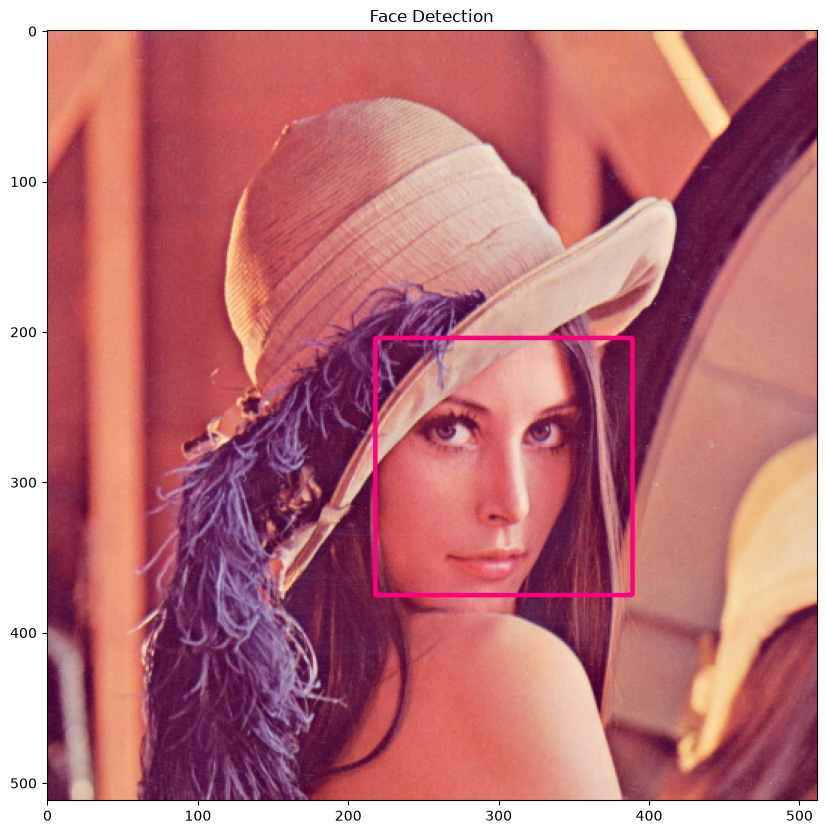

In [2]:
# We point OpenCV's CascadeClassifier function to where our 
# classifier (XML file format) is stored
face_classifier = cv2.CascadeClassifier('assets/haarcascades/Haarcascades/haarcascade_frontalface_default.xml')

# Load our image then convert it to grayscale
image = cv2.imread('assets/images/Trump.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Our classifier returns the ROI of the detected face as a tuple
# It stores the top left coordinate and the bottom right coordiantes
faces = face_classifier.detectMultiScale(gray, scaleFactor = 1.3, minNeighbors = 5)

# When no faces detected, face_classifier returns and empty tuple
if faces is ():
    print("No faces found")

# We iterate through our faces array and draw a rectangle
# over each face in faces
for (x,y,w,h) in faces:
    cv2.rectangle(image, (x,y), (x+w,y+h), (127,0,255), 2)

imshow('Face Detection', image)

In [3]:
import numpy as np

# A tiny 5x5 patch and its integral image, to make "O(1) rectangle sum" concrete.
patch = np.array([
    [1, 2, 3, 0, 1],
    [4, 5, 6, 1, 2],
    [7, 8, 9, 2, 1],
    [1, 1, 1, 1, 1],
    [2, 2, 2, 2, 2],
])
integral = patch.cumsum(axis=0).cumsum(axis=1)
print('patch:\n', patch)
print('\nintegral image (running sum up-and-left of each point):\n', integral)

# Sum of the 3x3 block patch[0:3, 0:3] the slow way vs. the integral-image way.
# It's a corner block, so the '4-corner trick' collapses to a single lookup —
# for a block that doesn't start at (0,0) you'd do D - B - C + A for its 4 corners.
slow_sum = patch[0:3, 0:3].sum()
fast_sum = integral[2, 2]
print(f'\n3x3 block sum — brute force (9 additions): {slow_sum}, '
      f'integral-image lookup (1 lookup): {fast_sum}')

# A block that does NOT start at the corner, e.g. patch[1:4, 1:4]:
D = integral[3, 3]   # bottom-right corner of the block
B = integral[0, 3]   # strip directly above it
C = integral[3, 0]   # strip directly to its left
A = integral[0, 0]   # corner double-counted by both B and C
print(f'patch[1:4, 1:4] sum — brute force: {patch[1:4, 1:4].sum()}, '
      f'4-corner formula (D-B-C+A): {D - B - C + A}')

patch:
 [[1 2 3 0 1]
 [4 5 6 1 2]
 [7 8 9 2 1]
 [1 1 1 1 1]
 [2 2 2 2 2]]

integral image (running sum up-and-left of each point):
 [[ 1  3  6  6  7]
 [ 5 12 21 22 25]
 [12 27 45 48 52]
 [13 29 48 52 57]
 [15 33 54 60 67]]

3x3 block sum — brute force (9 additions): 45, integral-image lookup (1 lookup): 45
patch[1:4, 1:4] sum — brute force: 34, 4-corner formula (D-B-C+A): 34


## **Simple Eye & Face Detection using Haarcascade Classifiers**

<>:13: SyntaxWarning: "is" with 'tuple' literal. Did you mean "=="?
<>:13: SyntaxWarning: "is" with 'tuple' literal. Did you mean "=="?
/var/folders/x6/yz886ty90c5dbqzy0q8zqdsc0000gn/T/ipykernel_96524/2616507752.py:13: SyntaxWarning: "is" with 'tuple' literal. Did you mean "=="?
  if faces is ():


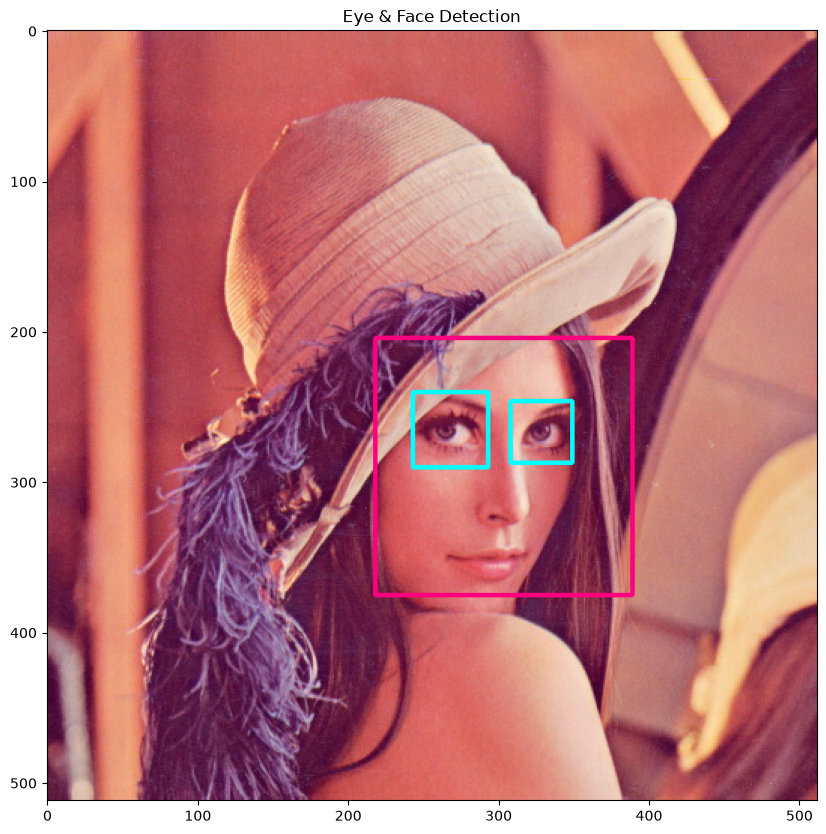

In [4]:
import numpy as np
import cv2
 
face_classifier = cv2.CascadeClassifier('assets/haarcascades/Haarcascades/haarcascade_frontalface_default.xml')
eye_classifier = cv2.CascadeClassifier('assets/haarcascades/Haarcascades/haarcascade_eye.xml')
 
img = cv2.imread('assets/images/Trump.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_classifier.detectMultiScale(gray, 1.3, 5)

# When no faces detected, face_classifier returns and empty tuple
if faces is ():
    print("No Face Found")

for (x,y,w,h) in faces:
    cv2.rectangle(img,(x,y),(x+w,y+h),(127,0,255),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]
    eyes = eye_classifier.detectMultiScale(roi_gray, 1.2, 3)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(255,255,0),2)

imshow('Eye & Face Detection',img)

## **Using access the webcam for an input**

Note: Requires your computer to have a webcam

In [5]:
import cv2

def take_photo(filename='photo.jpg', quality=0.8):
    # Open the default camera
    cap = cv2.VideoCapture(0)

    # Check if the camera opened successfully
    if not cap.isOpened():
        print("Error: Could not open camera")
        return None

    # Capture frame-by-frame
    ret, frame = cap.read()

    # If frame is read correctly, write it to the file
    if ret:
        cv2.imwrite(filename, frame, [int(cv2.IMWRITE_JPEG_QUALITY), int(quality * 100)])

    # Release the camera
    cap.release()

    return filename


In [6]:
from IPython.display import Image
try:
  filename = take_photo()
  if filename:
    print('Saved to {}'.format(filename))
    # Show the image which was just taken.
    display(Image(filename))
  else:
    print('No webcam available in this environment — skipping live capture. '
          'The next cell falls back to images/Trump.jpg so the pipeline still runs end to end.')
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

[08/31 11:16:33.383855][info][8643089][Context.cpp:69] Context created with config: default config!
[08/31 11:16:33.383880][info][8643089][Context.cpp:74] Context work_dir=/Users/agasthya/RnD/Image-Processing-Techniques
[08/31 11:16:33.383881][info][8643089][Context.cpp:77] 	- SDK version: 1.9.4
[08/31 11:16:33.383882][info][8643089][Context.cpp:78] 	- SDK stage version: main
[08/31 11:16:33.383883][info][8643089][Context.cpp:82] get config EnumerateNetDevice:false
[08/31 11:16:33.383884][info][8643089][MacPal.cpp:36] createObPal: create MacPal!
[08/31 11:16:33.384387][info][8643089][MacPal.cpp:104] Create PollingDeviceWatcher!
[08/31 11:16:33.384391][info][8643089][DeviceManager.cpp:15] Current found device(s): (0)
[08/31 11:16:33.384393][info][8643089][Pipeline.cpp:15] Try to create pipeline with default device.
[08/31 11:16:33.384394][warning][8643089][ObException.cpp:5] No device found, fail to create pipeline!
[08/31 11:16:33.385441][info][8643089][Context.cpp:90] Context destroye

OpenCV: camera access has been denied. Either run 'tccutil reset Camera' command in same terminal to reset application authorization status, either modify 'System Preferences -> Security & Privacy -> Camera' settings for your application.
OpenCV: camera failed to properly initialize!
[ WARN:0@0.462] global cap.cpp:323 open VIDEOIO(OBSENSOR): raised unknown C++ exception!




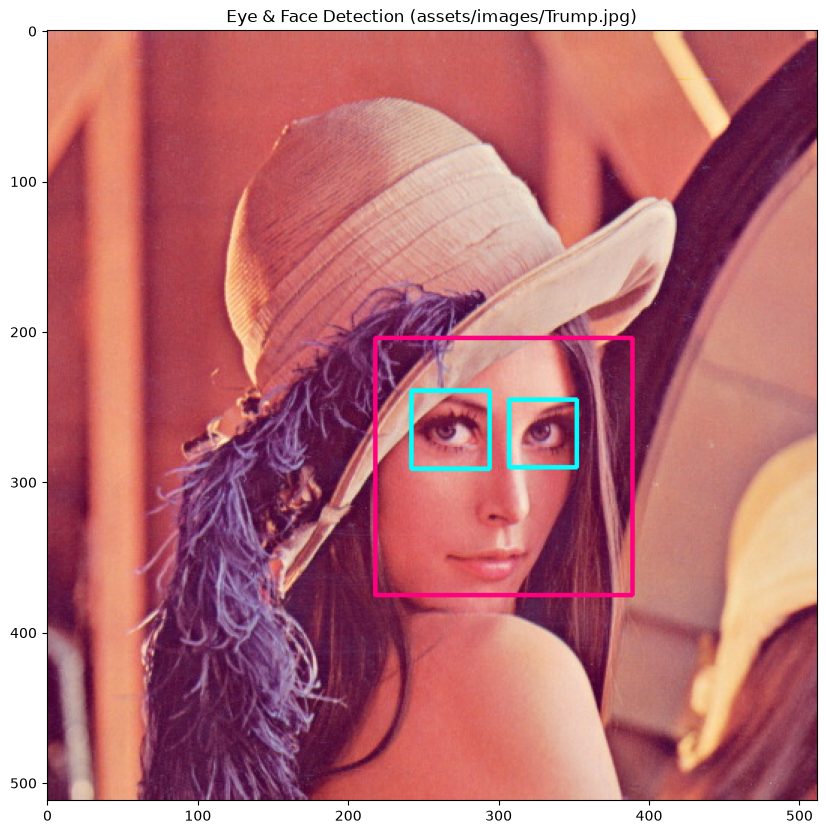

In [7]:
import os
import numpy as np
import cv2

face_classifier = cv2.CascadeClassifier('assets/haarcascades/Haarcascades/haarcascade_frontalface_default.xml')
eye_classifier = cv2.CascadeClassifier('assets/haarcascades/Haarcascades/haarcascade_eye.xml')

# Fall back to the bundled sample face if no webcam photo was captured above —
# keeps this cell runnable in any environment, headless or not.
photo_path = 'photo.jpg' if os.path.exists('photo.jpg') else 'assets/images/Trump.jpg'
img = cv2.imread(photo_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_classifier.detectMultiScale(gray, 1.3, 5)

if len(faces) == 0:
    print('No Face Found')

for (x,y,w,h) in faces:
    cv2.rectangle(img,(x,y),(x+w,y+h),(127,0,255),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]
    eyes = eye_classifier.detectMultiScale(roi_gray)
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(255,255,0),2)

imshow(f'Eye & Face Detection ({photo_path})', img)

### **Using webcam to do live face and eye detection**

In [8]:
import cv2
import numpy as np
from nb_utils import save_gif, show_gif

face_classifier = cv2.CascadeClassifier('assets/haarcascades/Haarcascades/haarcascade_frontalface_default.xml')
eye_classifier = cv2.CascadeClassifier('assets/haarcascades/Haarcascades/haarcascade_eye.xml')

def face_detector(img, size=0.5):
    # Convert image to grayscale
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    faces = face_classifier.detectMultiScale(gray, 1.3, 5)
    if len(faces) == 0:
        return img

    for (x,y,w,h) in faces:
        x = max(0, x - 50)
        w = w + 50
        y = max(0, y - 50)
        h = h + 50
        cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_classifier.detectMultiScale(roi_gray)

        for (ex,ey,ew,eh) in eyes:
            cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,0,255),2)
    return img

# cv2.imshow()/cv2.waitKey() never work inside a notebook (no GUI event loop —
# this is the crash the original version of this cell hit). Instead: grab a
# fixed batch of frames, run the detector on each, and play the result back as
# an inline GIF — the notebook-safe equivalent of a live preview window.
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print('No webcam available in this environment — skipping live detection.\n'
          'Run this cell locally on a machine with a camera to try it for real; '
          'the loop below is written to be notebook-safe when one is present.')
else:
    frames = []
    for _ in range(60):  # ~a few seconds at typical webcam FPS
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(face_detector(frame))
    cap.release()
    if frames:
        gif_path = save_gif(frames, 'live_face_detection.gif', fps=10, resize_width=480)
        show_gif(gif_path)

[08/31 11:16:33.542381][info][8643089][Context.cpp:69] Context created with config: default config!
[08/31 11:16:33.542394][info][8643089][Context.cpp:74] Context work_dir=/Users/agasthya/RnD/Image-Processing-Techniques
[08/31 11:16:33.542395][info][8643089][Context.cpp:77] 	- SDK version: 1.9.4
[08/31 11:16:33.542395][info][8643089][Context.cpp:78] 	- SDK stage version: main
[08/31 11:16:33.542397][info][8643089][Context.cpp:82] get config EnumerateNetDevice:false
[08/31 11:16:33.542398][info][8643089][MacPal.cpp:36] createObPal: create MacPal!
[08/31 11:16:33.542495][info][8643089][MacPal.cpp:104] Create PollingDeviceWatcher!
[08/31 11:16:33.542498][info][8643089][DeviceManager.cpp:15] Current found device(s): (0)
[08/31 11:16:33.542499][info][8643089][Pipeline.cpp:15] Try to create pipeline with default device.
[08/31 11:16:33.542500][warning][8643089][ObException.cpp:5] No device found, fail to create pipeline!
[08/31 11:16:33.542592][info][8643089][Context.cpp:90] Context destroye

OpenCV: camera access has been denied. Either run 'tccutil reset Camera' command in same terminal to reset application authorization status, either modify 'System Preferences -> Security & Privacy -> Camera' settings for your application.
OpenCV: camera failed to properly initialize!
[ WARN:0@0.619] global cap.cpp:323 open VIDEOIO(OBSENSOR): raised unknown C++ exception!




### Worth a second look

- Haar cascades are fast but coarse — swap in `cv2.dnn.readNetFromCaffe`'s res10 SSD face detector (bundled with OpenCV's samples) on `images/Trump.jpg` and compare false-positive rates.
- Blur every detected face automatically: `cv2.GaussianBlur` the `roi_color` slice in place before displaying — the basis of most privacy-blur camera filters.